In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

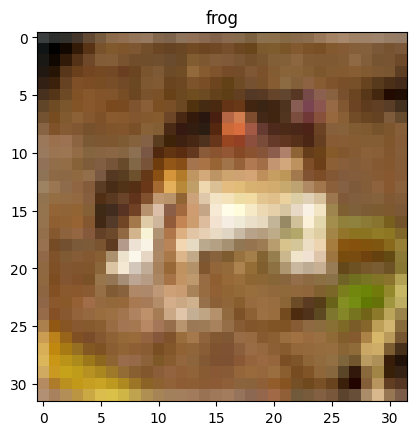

In [5]:
plt.imshow(x_train[0])
plt.title(class_names[y_train[0][0]])
plt.show()

In [6]:
model = keras.Sequential([

    # Convolution Layer 1
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    # Convolution Layer 2
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    # Convolution Layer 3
    keras.layers.Conv2D(64, (3,3), activation='relu'),

    # Flatten + Dense Layers
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.4495 - loss: 1.5142 - val_accuracy: 0.5510 - val_loss: 1.2498
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6011 - loss: 1.1310 - val_accuracy: 0.6135 - val_loss: 1.0883
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6550 - loss: 0.9803 - val_accuracy: 0.6555 - val_loss: 0.9815
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6884 - loss: 0.8814 - val_accuracy: 0.6780 - val_loss: 0.9110
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7167 - loss: 0.8077 - val_accuracy: 0.6893 - val_loss: 0.8932
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7360 - loss: 0.7520 - val_accuracy: 0.7039 - val_loss: 0.8623
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7529 - loss: 0.7007 - val_accuracy: 0.7156 - val_loss: 0.8297
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7676 - loss: 0.6583 

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7076 - loss: 0.8884
Test Accuracy: 0.7075999975204468


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


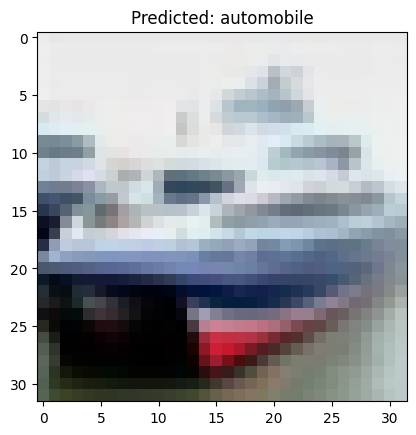

In [10]:
predictions = model.predict(x_test)

plt.imshow(x_test[1])
plt.title("Predicted: " + class_names[np.argmax(predictions[1])])
plt.show()

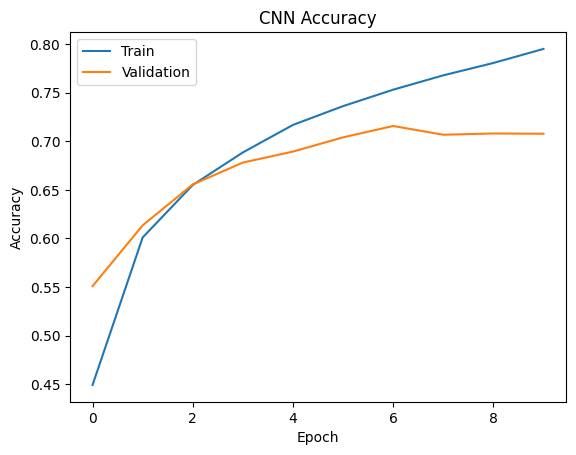

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# 📘 Cell-wise Explanation of CNN using CIFAR-10

### 🔹 Cell 1: Import Libraries

Imports TensorFlow/Keras for deep learning, NumPy for computations, and Matplotlib for visualization.

---

### 🔹 Cell 2: Load Dataset

Loads CIFAR-10 dataset containing 32×32 color images across 10 categories. Data is split into training and testing sets.

---

### 🔹 Cell 3: Normalize Data

Pixel values are scaled from 0–255 to 0–1 to improve training efficiency and convergence.

---

### 🔹 Cell 4: Define Class Names

Stores category labels for easy interpretation of predictions.

---

### 🔹 Cell 5: Display Sample Image

Displays a sample image from the dataset along with its class label.

---

### 🔹 Cell 6: Build CNN Model

Defines the CNN architecture:

* Convolution layers extract spatial features
* MaxPooling reduces dimensions
* Flatten converts feature maps to vector
* Dense layers perform classification

---

### 🔹 Cell 7: Compile Model

Configures the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric.

---

### 🔹 Cell 8: Train Model

Trains the CNN for 10 epochs using training data and validates performance using test data.

---

### 🔹 Cell 9: Evaluate Model

Evaluates model accuracy on unseen test data.

---

### 🔹 Cell 10: Predictions

Predicts class labels for test images and displays results.

---

### 🔹 Cell 11: Accuracy Graph

Plots training and validation accuracy to analyze model performance.

---

# ✅ Conclusion

The CNN model successfully learned image features and classified objects from CIFAR-10 dataset, demonstrating the effectiveness of convolutional layers in image processing tasks.


# 📊 Dataset Description: CIFAR-10 Dataset

### 📌 Description

The CIFAR-10 dataset consists of small color images representing real-world objects. It is commonly used to evaluate Convolutional Neural Networks (CNNs) due to its higher complexity compared to MNIST.

### 📊 Features

* Each image is **32 × 32 pixels**
* Contains **3 color channels (RGB)**
* Total features per image: **3072 (32×32×3)**
* Pixel values range from **0 to 255**

### 🎯 Target Variable

* Each image belongs to one of the following 10 classes:
  Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck
* Type: **Multi-class classification**

### 📦 Dataset Size

* Training samples: **50,000 images**
* Testing samples: **10,000 images**
* Total samples: **60,000 images**

### ⭐ Key Characteristics

* Contains real-world object images
* More complex than MNIST due to color and variability
* Includes variations in background, lighting, and object orientation
* Suitable for testing deep CNN architectures
